# Projekt II- Wizualizacja i przetwarzanie danych
### Paula Sopala

## Wstęp

Celem projektu jest analiza danych dotyczących korzystania z mediów społecznościowych przez studentów oraz zbadanie potencjalnego wpływu tego zjawiska na sen, zdrowie psychiczne i wyniki w nauce.

Projekt ma charakter eksploracyjny i koncentruje się na analizie zależności pomiędzy zmiennymi oraz na przetwarzaniu danych z wykorzystaniem narzędzi do analizy i wizualizacji danych w Pythonie.

### Źródło danych

Dane wykorzystane w projekcie pochodzą z serwisu Kaggle:
https://www.kaggle.com/datasets/zahranusratt/student-social-media-addiction-analysis-dataset

Zbiór danych: **Student Social Media Addiction Analysis Dataset**

### Import bibliotek

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

### Wczytanie danych

In [2]:
df = pd.read_csv("Students Social Media Addiction.csv")
df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


In [3]:
df.shape

(705, 13)

Zbiór danych zawiera wiersze odpowiadające 705 studentom oraz 13 kolumn opisujących
różne aspekty ich życia i korzystania z mediów społecznościowych.

### Opis kolumn:

- **Student_ID** – unikalny identyfikator studenta  
- **Age** – wiek studenta  
- **Gender** – płeć  
- **Academic_Level** – poziom edukacji (High School / Undergraduate / Graduate)  
- **Country** – kraj pochodzenia  
- **Avg_Daily_Social_Media_Use** – średni dzienny czas korzystania z social mediów (w godzinach)  
- **Most_Used_Platform** – najczęściej używana platforma społecznościowa  
- **Affects_Academic_Performance** – czy social media wpływają na wyniki w nauce (Yes / No)  
- **Sleep_Hours** – średnia liczba godzin snu  
- **Mental_Health_Score** – subiektywna ocena zdrowia psychicznego (skala numeryczna)  
- **Relationship_Status** – status relacji  
- **Conflicts_Over_Social_Media** – liczba konfliktów związanych z mediami społecznościowymi  
- **Addicted_Score** – poziom uzależnienia od social mediów (skala)

### Informacje o danych

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score                705 non-null    int64  
dtypes: fl

Analiza typów danych pozwala określić, które kolumny mają charakter numeryczny,
a które kategoryczny.

In [5]:
df.isna().sum()

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Relationship_Status             0
Conflicts_Over_Social_Media     0
Addicted_Score                  0
dtype: int64

Zbiór danych nie zawiera brakujących wartości, a typy danych są spójne,
co umożliwia bezpośrednie przejście do etapu analizy.

### Czyszczenie i przygotowanie danych

In [6]:
df = df.copy()

cat_cols = [
    "Gender", "Academic_Level", "Country",
    "Most_Used_Platform", "Affects_Academic_Performance",
    "Relationship_Status"
]

for c in cat_cols:
    df[c] = df[c].str.strip()

### Analiza opisowa danych

In [7]:
df.describe()

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score
count,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000
mean,353.000000,20.659574,4.918723,6.868936,6.226950,2.849645,6.436879
std,203.660256,1.399217,1.257395,1.126848,1.105055,0.957968,1.587165
min,1.000000,18.000000,1.500000,3.800000,4.000000,0.000000,2.000000
25%,177.000000,19.000000,4.100000,6.000000,5.000000,2.000000,5.000000
50%,353.000000,21.000000,4.800000,6.900000,6.000000,3.000000,7.000000
75%,529.000000,22.000000,5.800000,7.700000,7.000000,4.000000,8.000000
max,705.000000,24.000000,8.500000,9.600000,9.000000,5.000000,9.000000


In [8]:
num_cols = df.select_dtypes(include="number").columns

df[num_cols].agg(["min", "max"])

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score
min,1,18,1.5,3.8,4,0,2
max,705,24,8.5,9.6,9,5,9


### Struktura próby wg płci

In [9]:
gender_table = (
    df["Gender"]
    .value_counts()
    .to_frame(name="Liczba")
)

gender_table["Udział [%]"] = (
    df["Gender"].value_counts(normalize=True) * 100
).round(2)

gender_table

,Liczba,Udział [%]
Gender,,
Female,353,50.07
Male,352,49.93


Próba badawcza jest prawie równomiernie podzielona pomiędzy kobiety i mężczyzn,
co ogranicza ryzyko stronniczości wyników ze względu na płeć.

### Rozkład czasu spędzanego w mediach społecznościowych

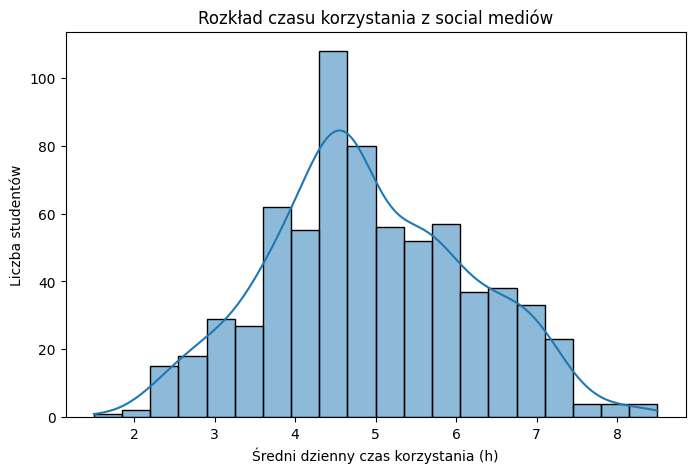

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["Avg_Daily_Usage_Hours"], bins=20, kde=True)
plt.xlabel("Średni dzienny czas korzystania (h)")
plt.ylabel("Liczba studentów")
plt.title("Rozkład czasu korzystania z social mediów")
plt.show()

Większość studentów spędza w mediach społecznościowych kilka godzin dziennie (4-6h),
jednak występuje również grupa intensywnych użytkowników (>7h).

### Najczęściej używane platformy

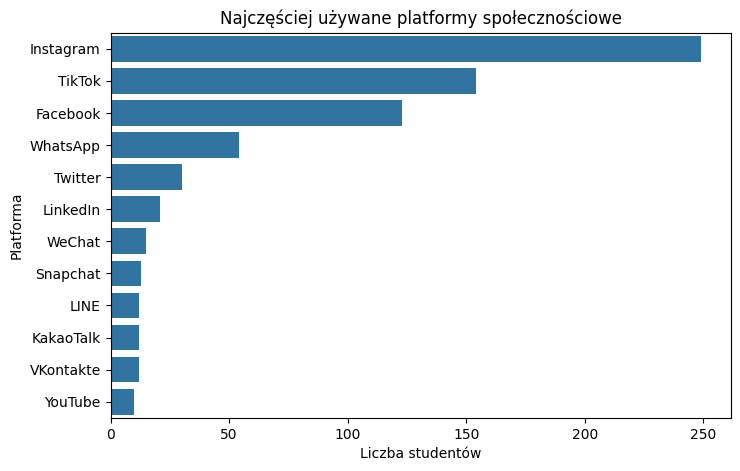

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, y="Most_Used_Platform", order=df["Most_Used_Platform"].value_counts().index)
plt.title("Najczęściej używane platformy społecznościowe")
plt.xlabel("Liczba studentów")
plt.ylabel("Platforma")
plt.show()

Najpopularniejszymi platformami wśród studentów są Instagram oraz TikTok.

### Social media a sen

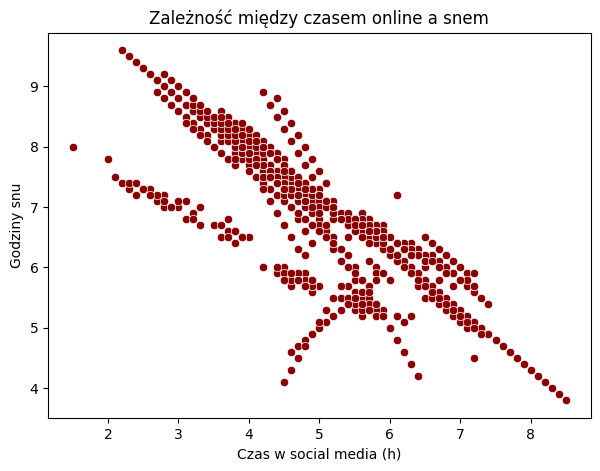

In [33]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x="Avg_Daily_Usage_Hours",
    y="Sleep_Hours_Per_Night",
    color="darkred"
)
plt.xlabel("Czas w social media (h)")
plt.ylabel("Godziny snu")
plt.title("Zależność między czasem online a snem")
plt.show()

Wraz ze wzrostem czasu korzystania
z mediów społecznościowych skraca się średnia liczba godzin snu.

### Wpływ na wyniki w nauce

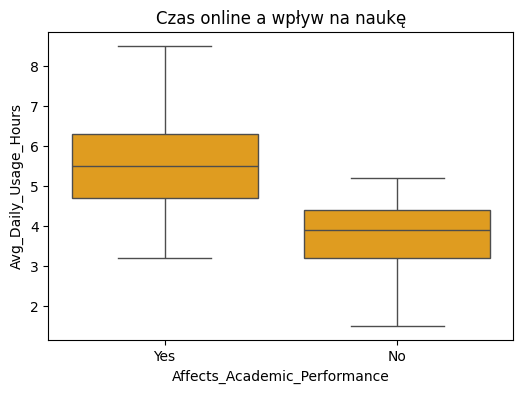

In [32]:
plt.figure(figsize=(6,4))
sns.boxplot(
    data=df,
    x="Affects_Academic_Performance",
    y="Avg_Daily_Usage_Hours",
    color="orange"
)
plt.title("Czas online a wpływ na naukę")
plt.show()

Studenci deklarujący negatywny wpływ social mediów na naukę
spędzają średnio więcej czasu online.

### Wiek a korzystanie z social mediów

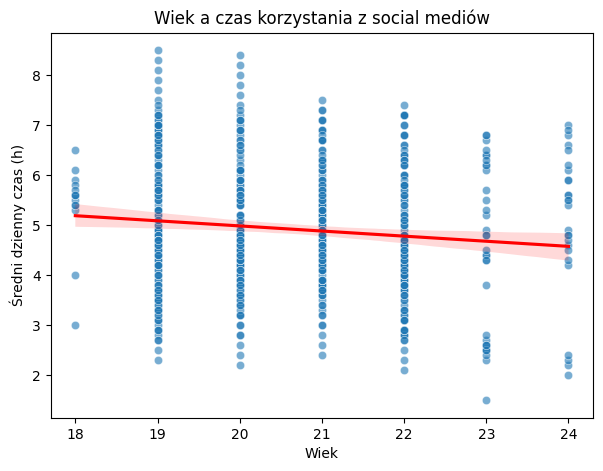

In [14]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x="Age",
    y="Avg_Daily_Usage_Hours",
    alpha=0.6
)
sns.regplot(
    data=df,
    x="Age",
    y="Avg_Daily_Usage_Hours",
    scatter=False,
    color="red"
)
plt.title("Wiek a czas korzystania z social mediów")
plt.xlabel("Wiek")
plt.ylabel("Średni dzienny czas (h)")
plt.show()

Młodsi studenci wykazują tendencję do spędzania większej ilości czasu
w mediach społecznościowych niż studenci starsi,
choć zależność ta nie jest bardzo silna.

### Kraje pochodzenia studentów

In [15]:
# ile krajów i ile respondentów
n_countries = df["Country"].nunique()
n_obs = len(df)

n_countries, n_obs

(110, 705)

In [16]:
# sprawdzamy czy dane sa równomiernie rozłożone między kraje
country_share = (
    df["Country"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .to_frame(name="Udział [%]")
)

country_share.head(10)

,Udział [%]
Country,
India,7.52
USA,5.67
Canada,4.82
Denmark,3.83
Ireland,3.83
Turkey,3.83
Mexico,3.83
Spain,3.83
France,3.83


In [17]:
min_n = 20 # min liczba respondentów

valid_countries = (
    df["Country"]
    .value_counts()
    .loc[lambda x: x >= min_n]
    .index
)

In [18]:
rows = []

for country in valid_countries:
    sub = df[df["Country"] == country]
    rows.append({
        "Country": country,
        "Liczba respondentów": len(sub),
        "Średni Addicted_Score": sub["Addicted_Score"].mean(),
        "Mediana Addicted_Score": sub["Addicted_Score"].median()
    })

country_addiction_table = pd.DataFrame(rows).sort_values(
    "Średni Addicted_Score", ascending=False
)

country_addiction_table

,Country,Liczba respondentów,Średni Addicted_Score,Mediana Addicted_Score
1,USA,40,8.600000,9.0
0,India,53,7.509434,8.0
14,Bangladesh,20,7.500000,7.5
6,Mexico,27,7.370370,7.0
5,Turkey,27,7.333333,7.0
7,Spain,27,7.296296,7.0
10,UK,22,7.227273,7.0
2,Canada,34,6.705882,7.0
4,Ireland,27,6.444444,6.0
13,Russia,21,6.428571,5.0


## Indeks ryzyka problematycznego korzystania z social mediów

W tej części tworzę **Indeks Ryzyka**, który łączy kilka aspektów:
- wysoki czas korzystania,
- niski sen,
- wysoki poziom uzależnienia.

Celem jest identyfikacja studentów potencjalnie najbardziej narażonych
na negatywne skutki korzystania z social mediów.

In [19]:
# normalizacja zmiennych
df["usage_norm"] = (df["Avg_Daily_Usage_Hours"] - df["Avg_Daily_Usage_Hours"].min()) / \
                   (df["Avg_Daily_Usage_Hours"].max() - df["Avg_Daily_Usage_Hours"].min())

df["sleep_norm"] = 1 - (
    (df["Sleep_Hours_Per_Night"] - df["Sleep_Hours_Per_Night"].min()) /
    (df["Sleep_Hours_Per_Night"].max() - df["Sleep_Hours_Per_Night"].min())
)

df["addicted_norm"] = (df["Addicted_Score"] - df["Addicted_Score"].min()) / \
                       (df["Addicted_Score"].max() - df["Addicted_Score"].min())

In [20]:
df["Risk_Index"] = (
    0.4 * df["usage_norm"] +
    0.3 * df["sleep_norm"] +
    0.3 * df["addicted_norm"]
)

Indeks Ryzyka przyjmuje wartości od 0 do 1 – im wyższa wartość, tym potencjalnie
większe ryzyko problematycznego korzystania z social mediów.

In [21]:
df["Risk_Level"] = pd.cut(
    df["Risk_Index"],
    bins=[-0.01, 0.33, 0.66, 1.01],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

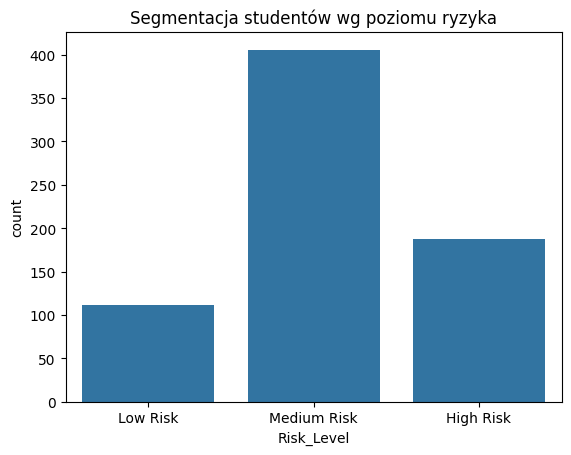

In [22]:
sns.countplot(data=df, x="Risk_Level")
plt.title("Segmentacja studentów wg poziomu ryzyka")
plt.show()

In [23]:
df.groupby("Risk_Level")[[
    "Avg_Daily_Usage_Hours",
    "Sleep_Hours_Per_Night",
    "Mental_Health_Score",
    "Addicted_Score"
]].mean()

,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Addicted_Score
Risk_Level,,,,
Low Risk,3.145045,8.267568,7.810811,4.054054
Medium Risk,4.695813,7.082266,6.349754,6.258621
High Risk,6.447340,5.582447,5.026596,8.228723


### Poziom edukacji a Indeks Ryzyka

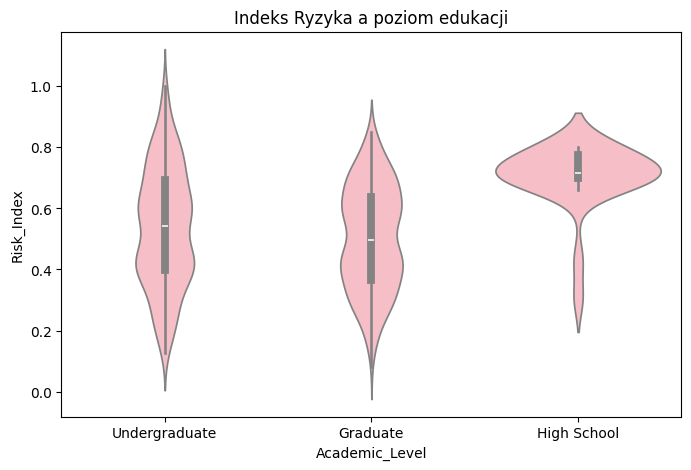

In [24]:
plt.figure(figsize=(8,5))
sns.violinplot(
    data=df,
    x="Academic_Level",
    y="Risk_Index",
    color="lightpink"
)
plt.title("Indeks Ryzyka a poziom edukacji")
plt.xlabel("Academic_Level")
plt.ylabel("Risk_Index")
plt.show()

Uczniowie szkół średnich wykazują przeciętnie wyższy poziom ryzyka
niż studenci studiów wyższych.

## Symulacja scenariusza: ograniczenie korzystania z social mediów

W tej części projektu przeprowadzono symulację hipotetycznego scenariusza,
w którym studenci ograniczają czas korzystania z mediów społecznościowych
o **1 godzinę dziennie**.

Symulacja ma charakter analityczny i nie stanowi prognozy,
a jedynie ilustrację potencjalnych zależności w danych.

In [25]:
df_sim = df.copy()

In [26]:
mask_heavy = df_sim["Avg_Daily_Usage_Hours"] > 5

df_sim["Avg_Daily_Usage_Hours_Sim"] = df_sim["Avg_Daily_Usage_Hours"]
df_sim.loc[mask_heavy, "Avg_Daily_Usage_Hours_Sim"] -= 2
df_sim["Avg_Daily_Usage_Hours_Sim"] = df_sim["Avg_Daily_Usage_Hours_Sim"].clip(lower=0)

In [27]:
usage_norm_sim = (
    df_sim["Avg_Daily_Usage_Hours_Sim"] - df_sim["Avg_Daily_Usage_Hours_Sim"].min()
) / (
    df_sim["Avg_Daily_Usage_Hours_Sim"].max() - df_sim["Avg_Daily_Usage_Hours_Sim"].min()
)

df_sim["Risk_Index_Sim"] = (
    0.4 * usage_norm_sim +
    0.3 * df_sim["sleep_norm"] +
    0.3 * df_sim["addicted_norm"]
)

#### Porównanie rozkładów Indeksu Ryzyka

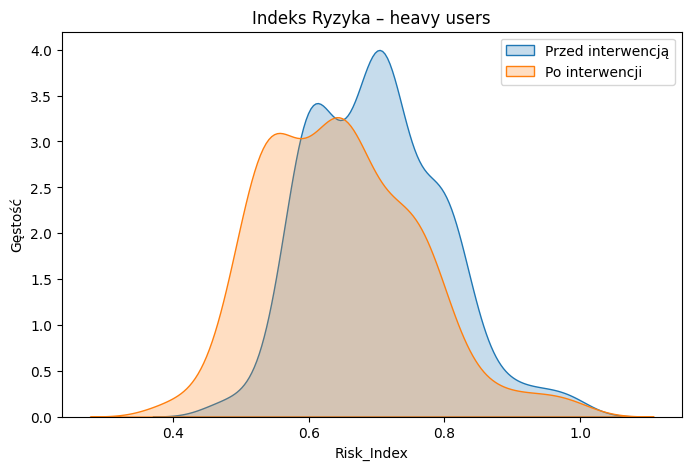

In [28]:
plt.figure(figsize=(8,5))
sns.kdeplot(
    df.loc[mask_heavy, "Risk_Index"],
    label="Przed interwencją",
    fill=True
)
sns.kdeplot(
    df_sim.loc[mask_heavy, "Risk_Index_Sim"],
    label="Po interwencji",
    fill=True
)
plt.title("Indeks Ryzyka – heavy users")
plt.xlabel("Risk_Index")
plt.ylabel("Gęstość")
plt.legend()
plt.show()

Symulacja pokazuje, że sama redukcja czasu korzystania o 1 godzinę
nie prowadzi do radykalnego spadku Indeksu Ryzyka.

### Regułowa klasyfikacja użytkowników

In [29]:
def classify_user(row):
    if row["Avg_Daily_Usage_Hours"] > 6 and row["Addicted_Score"] >= 7:
        return "Heavy user"
    elif row["Avg_Daily_Usage_Hours"] < 3:
        return "Light user"
    else:
        return "Moderate user"

df["User_Type"] = df.apply(classify_user, axis=1)

In [30]:
df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score,usage_norm,sleep_norm,addicted_norm,Risk_Index,Risk_Level,User_Type
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8,0.528571,0.534483,0.857143,0.628916,Medium Risk,Moderate user
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3,0.085714,0.362069,0.142857,0.185764,Low Risk,Light user
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9,0.642857,0.793103,1.000000,0.795074,High Risk,Moderate user
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4,0.214286,0.448276,0.285714,0.305911,Low Risk,Moderate user
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7,0.428571,0.620690,0.714286,0.571921,Medium Risk,Moderate user


Regułowa klasyfikacja stanowi intuicyjne uzupełnienie Indeksu Ryzyka
i pozwala na łatwą interpretację zachowań użytkowników.